# discNK: 最適裁量政策 (リファクタ版)

`quant_macro_book/chapter7/Julia/7_3_2_NstateNK/discNK.ipynb` のロジックを `src/` 配下のモジュールに分割し、
理解しやすさのために再構成したもの。出力 (図4・図5) はオリジナルと一致する。

モジュール構成:
- `src/nk_model.jl` — `Model` 構造体とデフォルトカリブレーション
- `src/shocks.jl` — `tauchen`, `cdf_normal`, 2変数ショック格子の構成
- `src/discretionary.jl` — 期待値計算, 非拘束ステップ, ZLB ステップ, 反復本体

In [1]:
using Plots
using LaTeXStrings

include("src/nk_model.jl")
include("src/shocks.jl")
include("src/discretionary.jl");

## カリブレーション

`default_model()` に discNK のオリジナル値を設定済み。

In [63]:
m = default_model()
println("β=$(m.bet), κ=$(m.kap), λ=$(m.lam), σ=$(m.sig)")

β=0.9913258983890954, κ=0.02439099324170912, λ=0.003, σ=6.25


## ショック格子の生成

Tauchen 法で実質金利ショック g とマークアップショック u を離散化し、Kronecker 積で同時分布の遷移行列を作る。

In [64]:
Gg, Pg = tauchen(m.Ng, m.sig*m.rstar, m.rhog, m.sigg, 3.0)
Gu, Pu = tauchen(m.Nu, 0.0, m.rhou, m.sigu, 3.0)
Gs, Ps = build_joint_shock_grid(Gg, Pg, Gu, Pu)
println("Ns = $(size(Gs,1)), grid g range = $(extrema(Gg)), grid u range = $(extrema(Gu))")

Ns = 961, grid g range = (-2.151250000000001, 13.088750000000001), grid u range = (-0.46199999999999997, 0.46199999999999997)


## 数値解の計算

`solve_discretionary` が時間反復法を実行する。

In [65]:
@time yvec0, pvec0, rvec0, iter = solve_discretionary(m; Gs=Gs, Ps=Ps)
println("Converged in $iter iterations.")

  0.103956 seconds (1.37 k allocations: 3.544 MiB)
Converged in 74 iterations.


## 政策関数の 2 次元配列化と図のプロット

In [66]:
ymat0 = zeros(m.Ng, m.Nu)
pmat0 = similar(ymat0)
rmat0 = similar(ymat0)
for ig in 1:m.Ng, iu in 1:m.Nu
    is = m.Nu * (ig - 1) + iu
    ymat0[ig, iu] = yvec0[is]
    pmat0[ig, iu] = pvec0[is]
    rmat0[ig, iu] = rvec0[is]
end

idu = Int(ceil(m.Nu/2))
edg = Int(ceil(m.Ng/2));

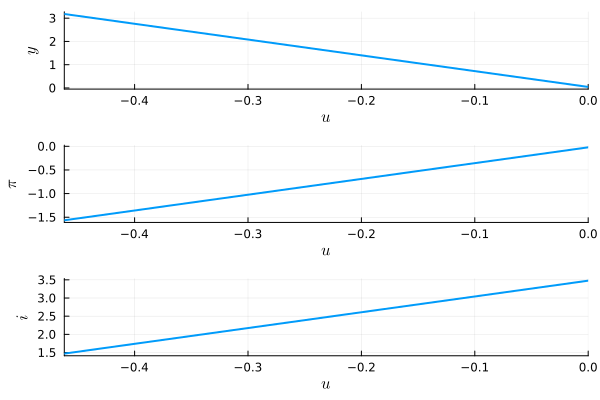

In [67]:
# Fig 4: マークアップショック u に対する政策関数 (g は中央値で固定)
p1 = plot(Gu[1:idu], ymat0[edg,1:idu], xlabel=L"u", ylabel=L"y", legend=false)
p2 = plot(Gu[1:idu], 4 .* pmat0[edg,1:idu], xlabel=L"u", ylabel=L"\pi", legend=false)
p3 = plot(Gu[1:idu], 4 .* rmat0[edg,1:idu], xlabel=L"u", ylabel=L"i", legend=false)
plot(p1, p2, p3, layout=(3,1), xlim=(Gu[1], Gu[idu]), xticks=(-0.4:0.1:0.0), linewidth=2)

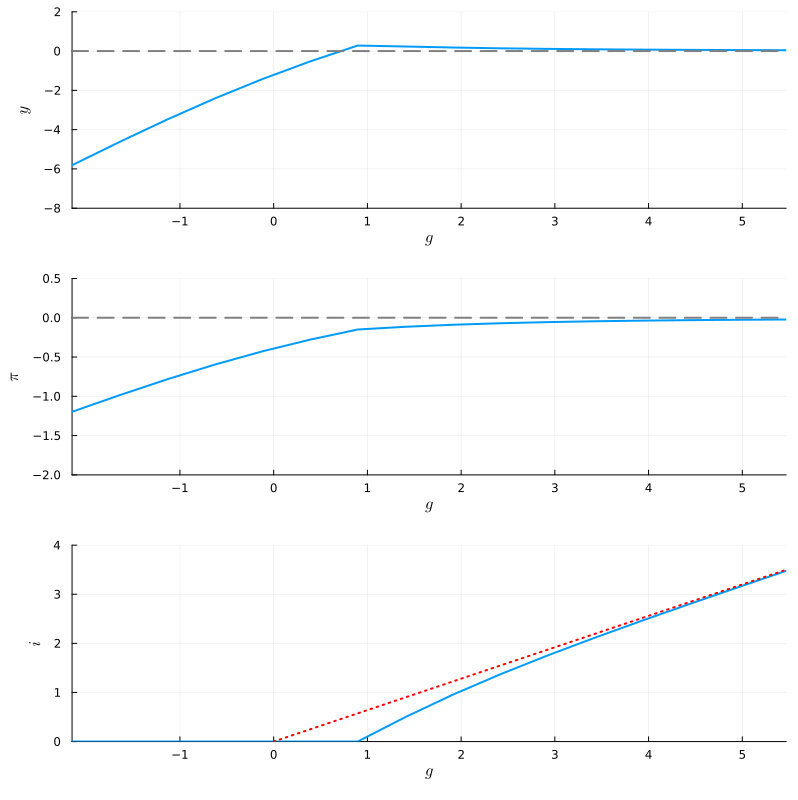

In [75]:
# Fig 5: 実質金利ショック g に対する政策関数 (u は中央値で固定)
p4 = plot(Gg[1:edg], ymat0[1:edg,idu], xlabel=L"g", ylabel=L"y", ylim=(-8,2), yticks=(-8:2:2), legend=false)
hline!(p4, [0], color=:gray, linestyle=:dash, linewidth=1)
p5 = plot(Gg[1:edg], 4 .* pmat0[1:edg,idu], xlabel=L"g", ylabel=L"\pi", ylim=(-2,0.5), yticks=(-2:0.5:0.5), legend=false)
hline!(p5, [0], color=:gray, linestyle=:dash, linewidth=1)
p6 = plot(Gg[1:edg], 4 .* rmat0[1:edg,idu], xlabel=L"g", ylabel=L"i", ylim=(0,4), yticks=(0:1:4), legend=false)
# plot!(p6, [Gg[1], Gg[edg]], [Gg[1], Gg[edg]], color=:gray, linestyle=:dash, linewidth=1)
plot!(p6, [Gg[1], Gg[edg]], 4 .* [Gg[1], Gg[edg]] ./ m.sig,
      color=:red, linestyle=:dot, linewidth=1, label="i = 4g/σ")

plot(p4, p5, p6, layout=(3,1), xlim=(Gg[1], Gg[edg]), xticks=(-1:1:5), linewidth=2, size=(800, 800))